# EfficientNet-B2 burned-area evaluation

**Purpose.** A single-model evaluation of EfficientNet-B2 deployed over Sentinel-2
tile T29TPG, combining the overlap experiment and the minimum fire-size sweep in
one place. It looks at how window overlap, voting strictness, and a minimum fire
size change the burned-area result, and at the cost of running the model over a
full tile.

**Dataset.** EfficientNet-B2 burned-area maps of tile T29TPG at 0, 25, 50 and 75
percent window overlap, before 2025-07-07 and after 2025-10-15, scored against the
ICNF fire records filtered to the window and clipped to Portugal.

**Objectives.** (1) Measure accuracy by overlap; (2) map the result; (3) measure
the cost; (4) test voting strictness; (5) test a minimum fire size; (6) draw the
threshold curves (ROC and precision-recall).

**Caveat.** The EfficientNet band order was taken from a config comment and is
pending confirmation with the model author, so treat these numbers as provisional.

## 1. Setup and data

This section loads the EfficientNet predictions and the ground truth.

### 1.1 Environment and plotting style

Import the libraries and set one clean style.

In [43]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import label as ndlabel

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MCOLOR = "#cc6677"                              # EfficientNet
C_AGREE = "#762a83"; C_FALSE = "#d6604d"; C_MISS = "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
cfg = load_config()

### 1.2 Load the EfficientNet predictions and study area

We use the EfficientNet-B2 maps at four overlaps. Vote-fraction rasters exist for
the 50 and 75 percent overlap runs (the ones with several windows per pixel).

In [44]:
MODEL = "efficientnet_b2"; MODEL_LABEL = "EfficientNet-B2"
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED = cfg.predictions_dir
LABELS = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01
OVERLAPS = [0, 25, 50, 75]          # overlaps with a burned map
VOTE_OVERLAPS = [50, 75]            # overlaps with a vote-fraction raster

def read(p):
    with rasterio.open(p) as r: return r.read(1)
def burned_path(ov):   return PRED / f"T29TPG_{MODEL}_ov{ov:02d}_{B}_{A}_burned.tif"
def votes_path(ov):    return PRED / f"T29TPG_{MODEL}_ov{ov:02d}_{B}_{A}_votes.tif"
def observed_path(ov): return PRED / f"T29TPG_{MODEL}_ov{ov:02d}_{B}_{A}_observed.tif"

labels_img = read(LABELS)
with rasterio.open(LABELS) as _r:
    GRID_T, GRID_SHAPE = _r.transform, (_r.height, _r.width)
    EXTENT = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                      transform=GRID_T, fill=0, dtype="uint8").astype(bool)
scored = (labels_img != 255) & inside_pt
comp = (read(observed_path(0)) == 1) & scored
print("overlaps with burned maps:", [ov for ov in OVERLAPS if burned_path(ov).exists()])
print("overlaps with vote rasters:", [ov for ov in VOTE_OVERLAPS if votes_path(ov).exists()])

overlaps with burned maps: [0, 25, 50, 75]
overlaps with vote rasters: [50, 75]


### 1.3 Ground truth within the window

Keep only ICNF fires that started on or after the before image and ended on or
before the after image, shrink each by one pixel, and rasterize.

In [45]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"]); fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                  transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp

def mcc(tp, fp, fn, tn):
    tp, fp, fn, tn = map(float, (tp, fp, fn, tn))
    d = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); return (tp*tn-fp*fn)/d if d else 0.0
def scores(pred):
    TP = int((pred & t).sum()); FP = int((pred & ~t).sum())
    FN = int((~pred & t).sum()); TN = int((~pred & ~t & comp).sum())
    return dict(burned_ha=(TP+FP)*PIX_HA, precision=TP/(TP+FP), recall=TP/(TP+FN),
                F1=2*TP/(2*TP+FP+FN), MCC=mcc(TP, FP, FN, TN))
def pool_or(a, k=12):
    H, W = (a.shape[0]//k)*k, (a.shape[1]//k)*k
    return a[:H, :W].reshape(H//k, k, W//k, k).max(axis=(1, 3))
def confusion_rgb(pred):
    TP, FP, FN = pool_or(pred & t), pool_or(pred & ~t), pool_or(~pred & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img
print(f"ground-truth fire in window: {t.sum()*PIX_HA:,.0f} ha")

ground-truth fire in window: 10,636 ha


## 2. Effect of window overlap

This section measures how sliding the inference window with overlap (and merging
the overlapping predictions by majority vote) changes the burned-area result and
what it costs.

### 2.1 Accuracy by overlap

We score the burned map at each overlap against the records.

#### 2.1.1 Burned area and scores

**Objective.** Compute burned area, precision, recall, F1 and MCC at 0, 25, 50 and
75 percent overlap. **Assumption.** Each map is the majority-vote burned mask.

In [46]:
rows = []
for ov in OVERLAPS:
    if not burned_path(ov).exists(): continue
    p = (read(burned_path(ov)) == 1) & comp
    rows.append({"overlap": ov, **scores(p)})
overlap_stats = pd.DataFrame(rows)
overlap_stats.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

,overlap,burned_ha,precision,recall,F1,MCC
0,0,17456.0,0.554,0.909,0.688,0.702
1,25,15586.0,0.620,0.909,0.737,0.745
2,50,15020.0,0.646,0.912,0.756,0.762
3,75,16040.0,0.613,0.925,0.737,0.747


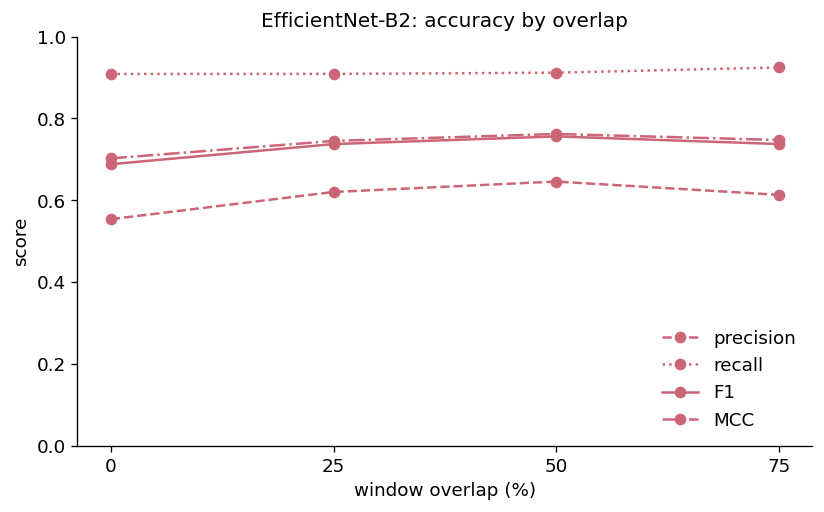

In [47]:
fig, ax = plt.subplots(figsize=(7, 4.4))
for metric, ls in [("precision", "--"), ("recall", ":"), ("F1", "-"), ("MCC", "-.")]:
    ax.plot(overlap_stats["overlap"], overlap_stats[metric], "o", linestyle=ls,
            color=MCOLOR, label=metric)
ax.set_xlabel("window overlap (%)"); ax.set_ylabel("score")
ax.set_xticks(OVERLAPS); ax.set_ylim(0, 1); ax.legend(loc="lower right")
ax.set_title(f"{MODEL_LABEL}: accuracy by overlap")
plt.tight_layout(); plt.show()

*Observation.* Overlapping the windows and voting filters scattered false
alarms, so precision and the summary scores rise with overlap while recall stays
high; the plain majority vote tends to peak around 50 percent overlap.

### 2.2 Spatial agreement

Where the model agrees with and departs from the records, at each overlap.

#### 2.2.1 Agreement maps by overlap

**Objective.** Map true positives (violet), false positives (red) and false
negatives (blue) at each overlap. **Assumption.** Maps are shrunk for display.

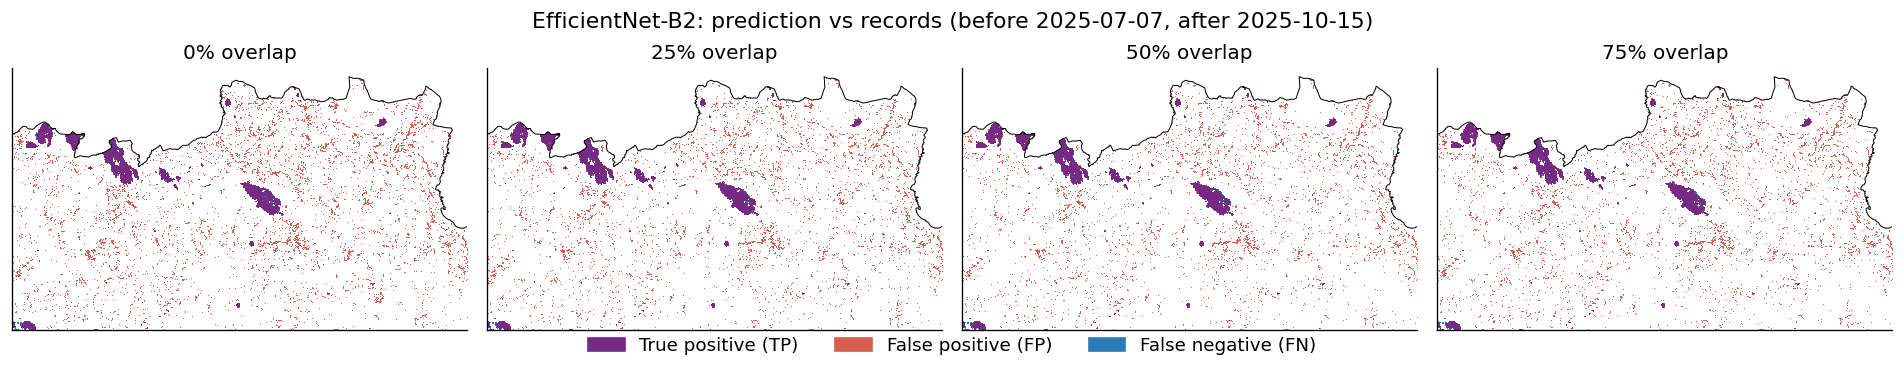

In [48]:
ovs = [ov for ov in OVERLAPS if burned_path(ov).exists()]
fig, axes = plt.subplots(1, len(ovs), figsize=(4*len(ovs), 3.0))
axes = np.atleast_1d(axes)
for ax, ov in zip(axes, ovs):
    p = (read(burned_path(ov)) == 1) & comp
    ax.imshow(confusion_rgb(p), extent=EXTENT, origin="upper", interpolation="nearest")
    PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{ov}% overlap")
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"{MODEL_LABEL}: prediction vs records (before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

*Observation.* The scattered red false positives thin out as overlap rises,
while the violet agreement on the real fires stays put.

*Question: what is the minimum pixel size of real documented fires, the false positives are patchy, whereas the true positives are opaque sections, maybe we can filter by 'patchiness' to exclude the false positives?

### 2.3 Computational cost

Run time and peak memory for the full-tile run at each overlap.

#### 2.3.1 Time and memory by overlap

**Objective.** Read run time, window count and peak memory from each run's
manifest. **Assumption.** Measured on CPU.

In [49]:
rows = []
for ov in OVERLAPS:
    mp = PRED / f"T29TPG_{MODEL}_ov{ov:02d}_{B}_{A}_manifest.json"
    if not mp.exists(): continue
    d = json.loads(mp.read_text())
    if d.get("elapsed_s") is None: continue
    rows.append({"overlap": ov, "time_min": d["elapsed_s"]/60,
                 "peak_GB": d["peak_rss_gb"], "n_windows": d["n_windows"]})
cost = pd.DataFrame(rows)
cost.round({"time_min": 2, "peak_GB": 2})

,overlap,time_min,peak_GB,n_windows
0,0,3.13,5.28,962
1,25,4.84,4.86,1683
2,50,10.26,5.10,3748
3,75,39.72,4.53,14628


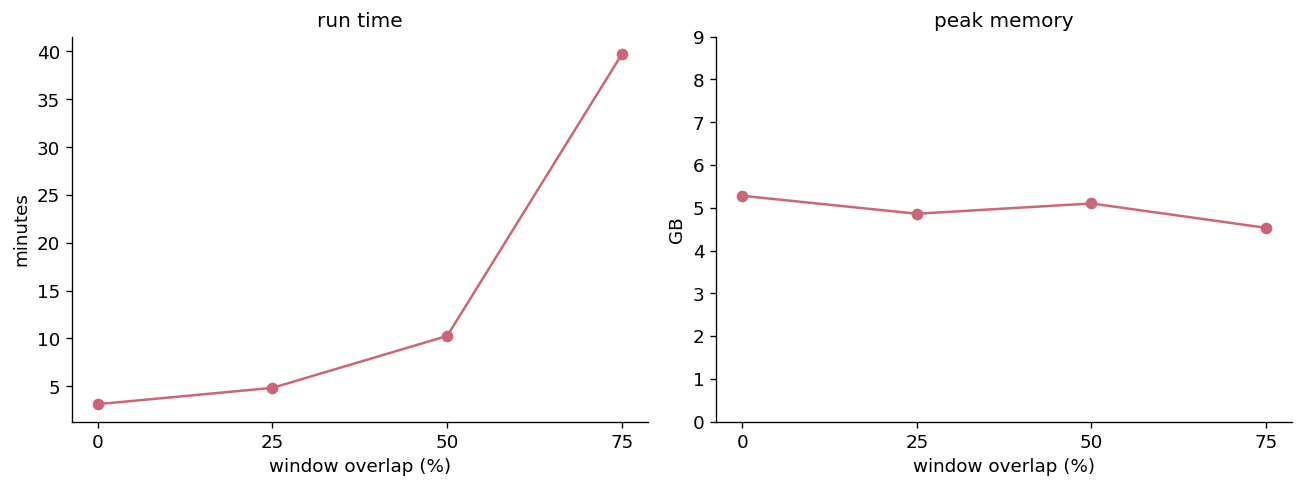

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(cost["overlap"], cost["time_min"], "o-", color=MCOLOR)
axes[0].set_title("run time"); axes[0].set_ylabel("minutes")
axes[1].plot(cost["overlap"], cost["peak_GB"], "o-", color=MCOLOR)
axes[1].set_title("peak memory"); axes[1].set_ylabel("GB"); axes[1].set_ylim(0, 9)
for ax in axes:
    ax.set_xlabel("window overlap (%)"); ax.set_xticks(OVERLAPS)
plt.tight_layout(); plt.show()

*Observation.* Run time climbs steeply toward 75 percent as the window count
explodes, while peak memory stays in a band set by rebuilding the two full images,
not by the overlap.

## 3. Voting strictness

With overlap each pixel is judged by several windows. Here we make the vote
stricter, requiring more of the covering windows to agree. Thresholds match the
coverage: at 50 percent overlap (up to 4 windows) we test 50 and 75 percent; at 75
percent overlap (up to 16 windows) we test 50 to 80 percent.

### 3.1 Scores by threshold and overlap

#### 3.1.1 Strictness table and curves

**Objective.** Score the burned class at each vote threshold and overlap.
**Assumption.** A pixel is burned if at least the threshold percent of its
covering windows voted burned.

In [51]:
STRICT_BY_OV = {50: [50, 75], 75: [50, 60, 70, 80]}
rows = []
for ov in VOTE_OVERLAPS:
    if not votes_path(ov).exists(): continue
    v = read(votes_path(ov))
    for thr in STRICT_BY_OV[ov]:
        p = (v != 255) & (v >= thr) & comp
        rows.append({"overlap": ov, "vote_pct": thr, **scores(p)})
strict_stats = pd.DataFrame(rows)
strict_stats.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

,overlap,vote_pct,burned_ha,precision,recall,F1,MCC
0,50,50,18618.0,0.534,0.935,0.680,0.700
1,50,75,14999.0,0.646,0.911,0.756,0.762
2,75,50,16852.0,0.588,0.931,0.721,0.734
3,75,60,15375.0,0.637,0.920,0.753,0.760
4,75,70,14145.0,0.683,0.908,0.779,0.782
5,75,80,13252.0,0.717,0.893,0.795,0.796


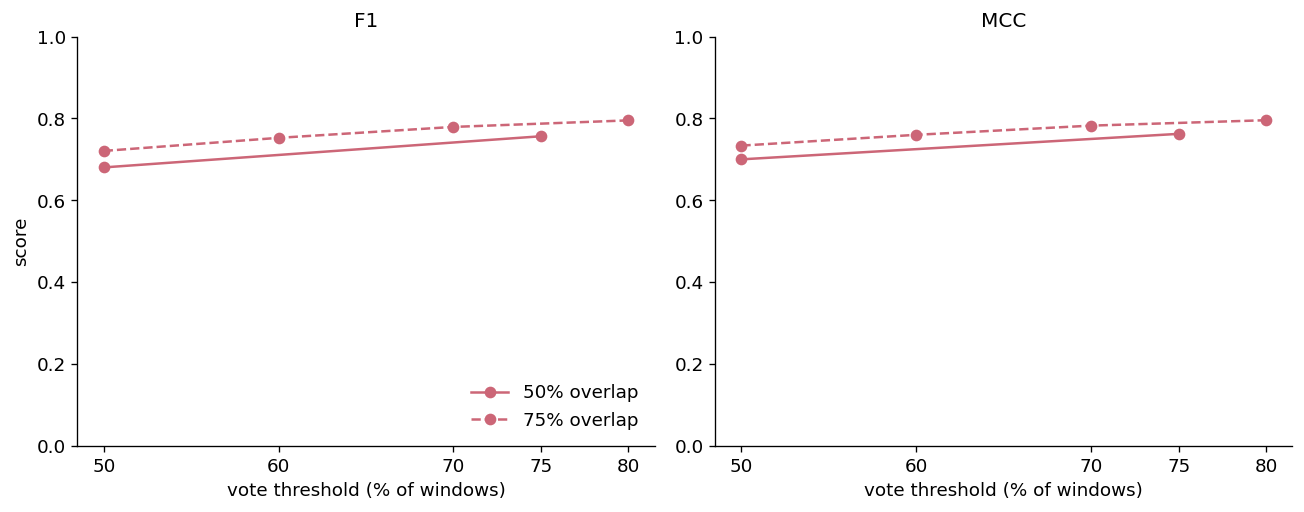

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, metric in zip(axes, ["F1", "MCC"]):
    for ov, g in strict_stats.groupby("overlap"):
        ls = "-" if ov == 50 else "--"
        ax.plot(g["vote_pct"], g[metric], "o", linestyle=ls, color=MCOLOR,
                label=f"{ov}% overlap")
    ax.set_title(metric); ax.set_xlabel("vote threshold (% of windows)")
    ax.set_xticks(sorted(strict_stats.vote_pct.unique())); ax.set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

*Observation.* A stricter vote raises F1 and MCC; 75 percent overlap keeps
improving across the finer range and reaches the highest scores, since its 16-window
coverage gives the strict vote more to work with.

### 3.2 Where the strict vote cleans up

#### 3.2.1 Agreement maps by vote threshold

**Objective.** Map agreement and error as the vote tightens, at 75 percent overlap.
**Assumption.** Maps shrunk for display.

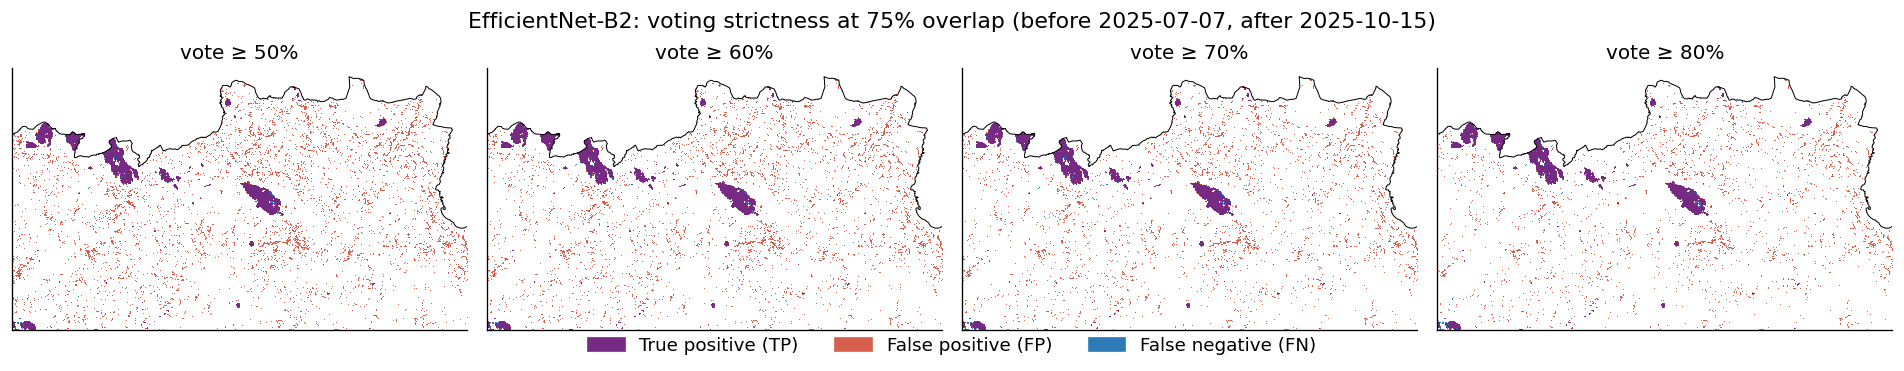

In [53]:
VOTE_OV_MAP = 75; THRS = [50, 60, 70, 80]
fig, axes = plt.subplots(1, len(THRS), figsize=(4*len(THRS), 3.0))
v = read(votes_path(VOTE_OV_MAP))
for ax, thr in zip(np.atleast_1d(axes), THRS):
    p = (v != 255) & (v >= thr) & comp
    ax.imshow(confusion_rgb(p), extent=EXTENT, origin="upper", interpolation="nearest")
    PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"vote ≥ {thr}%")
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"{MODEL_LABEL}: voting strictness at {VOTE_OV_MAP}% overlap "
             f"(before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

*Observation.* Left to right, the red false positives thin out while the
violet fires hold; a little blue (missed) appears only at the strictest vote.

*Interpretation.* increasing voting strictness reduces false positives (need to quanitfy by how much, get stats) but increases flase negatives so overall reduces the chances of a fire being detected. The importance of FP vs FN depends on the application of these findings, could be argued that it is more dangerous to miss a fire than to predict one where there was not.  

## 4. Minimum fire size

A separate clean-up: on the 50 percent overlap maps (at vote 50 and 75), we remove
predicted burned patches below a minimum size and re-score. It matters because the
leftover false alarms are mostly small scattered specks.

### 4.1 Size sweep on the 50 percent overlap maps

#### 4.1.1 Scores by vote and minimum size

**Objective.** Sweep the minimum size from 25 to 200 pixels at vote 50 and 75.
**Assumption.** Patches are connected components of the burned map; one pixel is
100 square metres.

In [54]:
VOTE_PCTS = [50, 75]; THRESHOLDS = list(range(25, 1001, 50))
patches = {}
v50 = read(votes_path(50))
for vp in VOTE_PCTS:
    lab, n = ndlabel((v50 != 255) & (v50 >= vp))
    patches[vp] = (lab, np.bincount(lab.ravel()))

def size_filtered(vp, min_size):
    lab, sizes = patches[vp]
    keep = sizes >= min_size; keep[0] = False
    return keep[lab] & comp

rows = []
for vp in VOTE_PCTS:
    for ms in THRESHOLDS:
        rows.append({"vote_pct": vp, "min_size_px": ms, **scores(size_filtered(vp, ms))})
size_stats = pd.DataFrame(rows)
size_stats.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

,vote_pct,min_size_px,burned_ha,precision,recall,F1,MCC
0,50,25,18525.0,0.537,0.935,0.682,0.702
1,50,75,16871.0,0.589,0.935,0.723,0.736
2,50,125,15686.0,0.633,0.934,0.755,0.764
3,50,175,14802.0,0.670,0.933,0.780,0.786
4,50,225,14169.0,0.699,0.932,0.799,0.803
5,50,275,13762.0,0.719,0.931,0.811,0.814
6,50,325,13357.0,0.740,0.930,0.824,0.826
7,50,375,13064.0,0.757,0.929,0.834,0.835
8,50,425,12860.0,0.768,0.929,0.841,0.842
9,50,475,12683.0,0.778,0.928,0.847,0.847


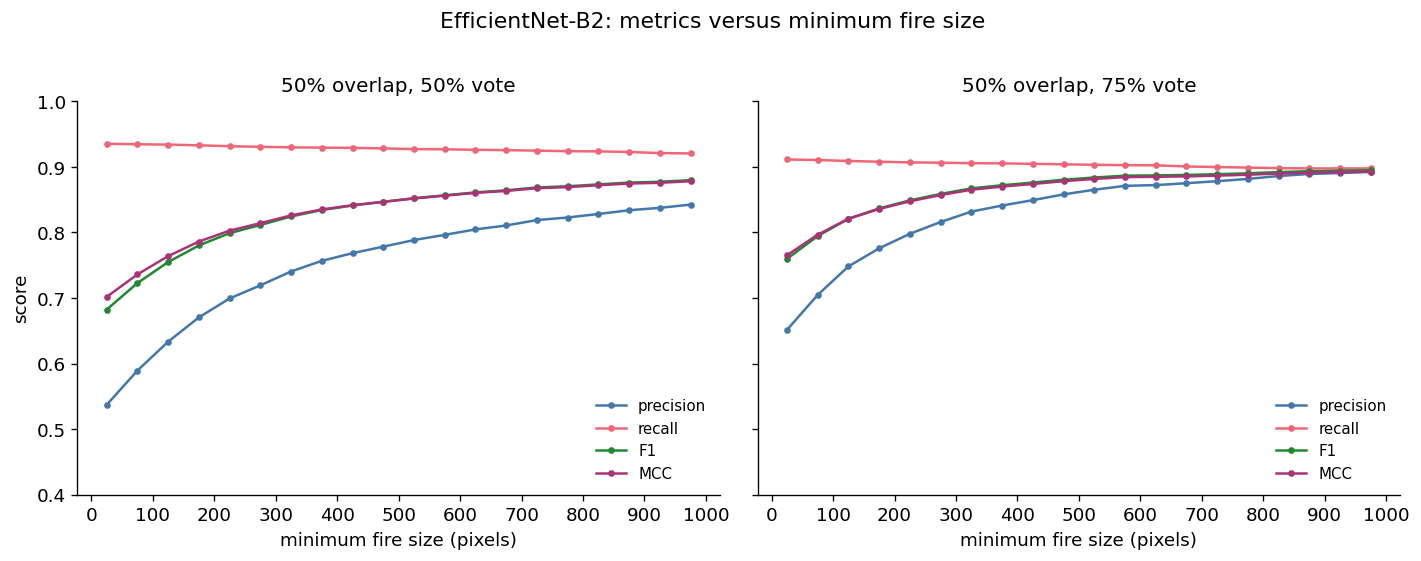

In [55]:
MET_COL = {"precision": "#4477aa", "recall": "#ee6677", "F1": "#228833", "MCC": "#aa3377"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, vp in zip(axes, VOTE_PCTS):
    g = size_stats[size_stats.vote_pct == vp].sort_values("min_size_px")
    for m in ["precision", "recall", "F1", "MCC"]:
        ax.plot(g["min_size_px"], g[m], "o-", ms=3, color=MET_COL[m], label=m)
    ax.set_title(f"50% overlap, {vp}% vote"); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(range(0, 1001, 100)); ax.set_ylim(0.4, 1); ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylabel("score")
fig.suptitle(f"{MODEL_LABEL}: metrics versus minimum fire size", y=1.01)
plt.tight_layout(); plt.show()

*Observation.* Raising the minimum size lifts precision, F1 and MCC at both
vote settings while recall barely moves, because real fires are far larger than the
threshold. The filter still helps after the vote has already removed some specks.

#### 4.1.2 Where the size filter cleans up

**Objective.** Map agreement and error at minimum sizes 25, 100 and 200 pixels, at
the 75 percent vote. **Assumption.** Maps shrunk for display.

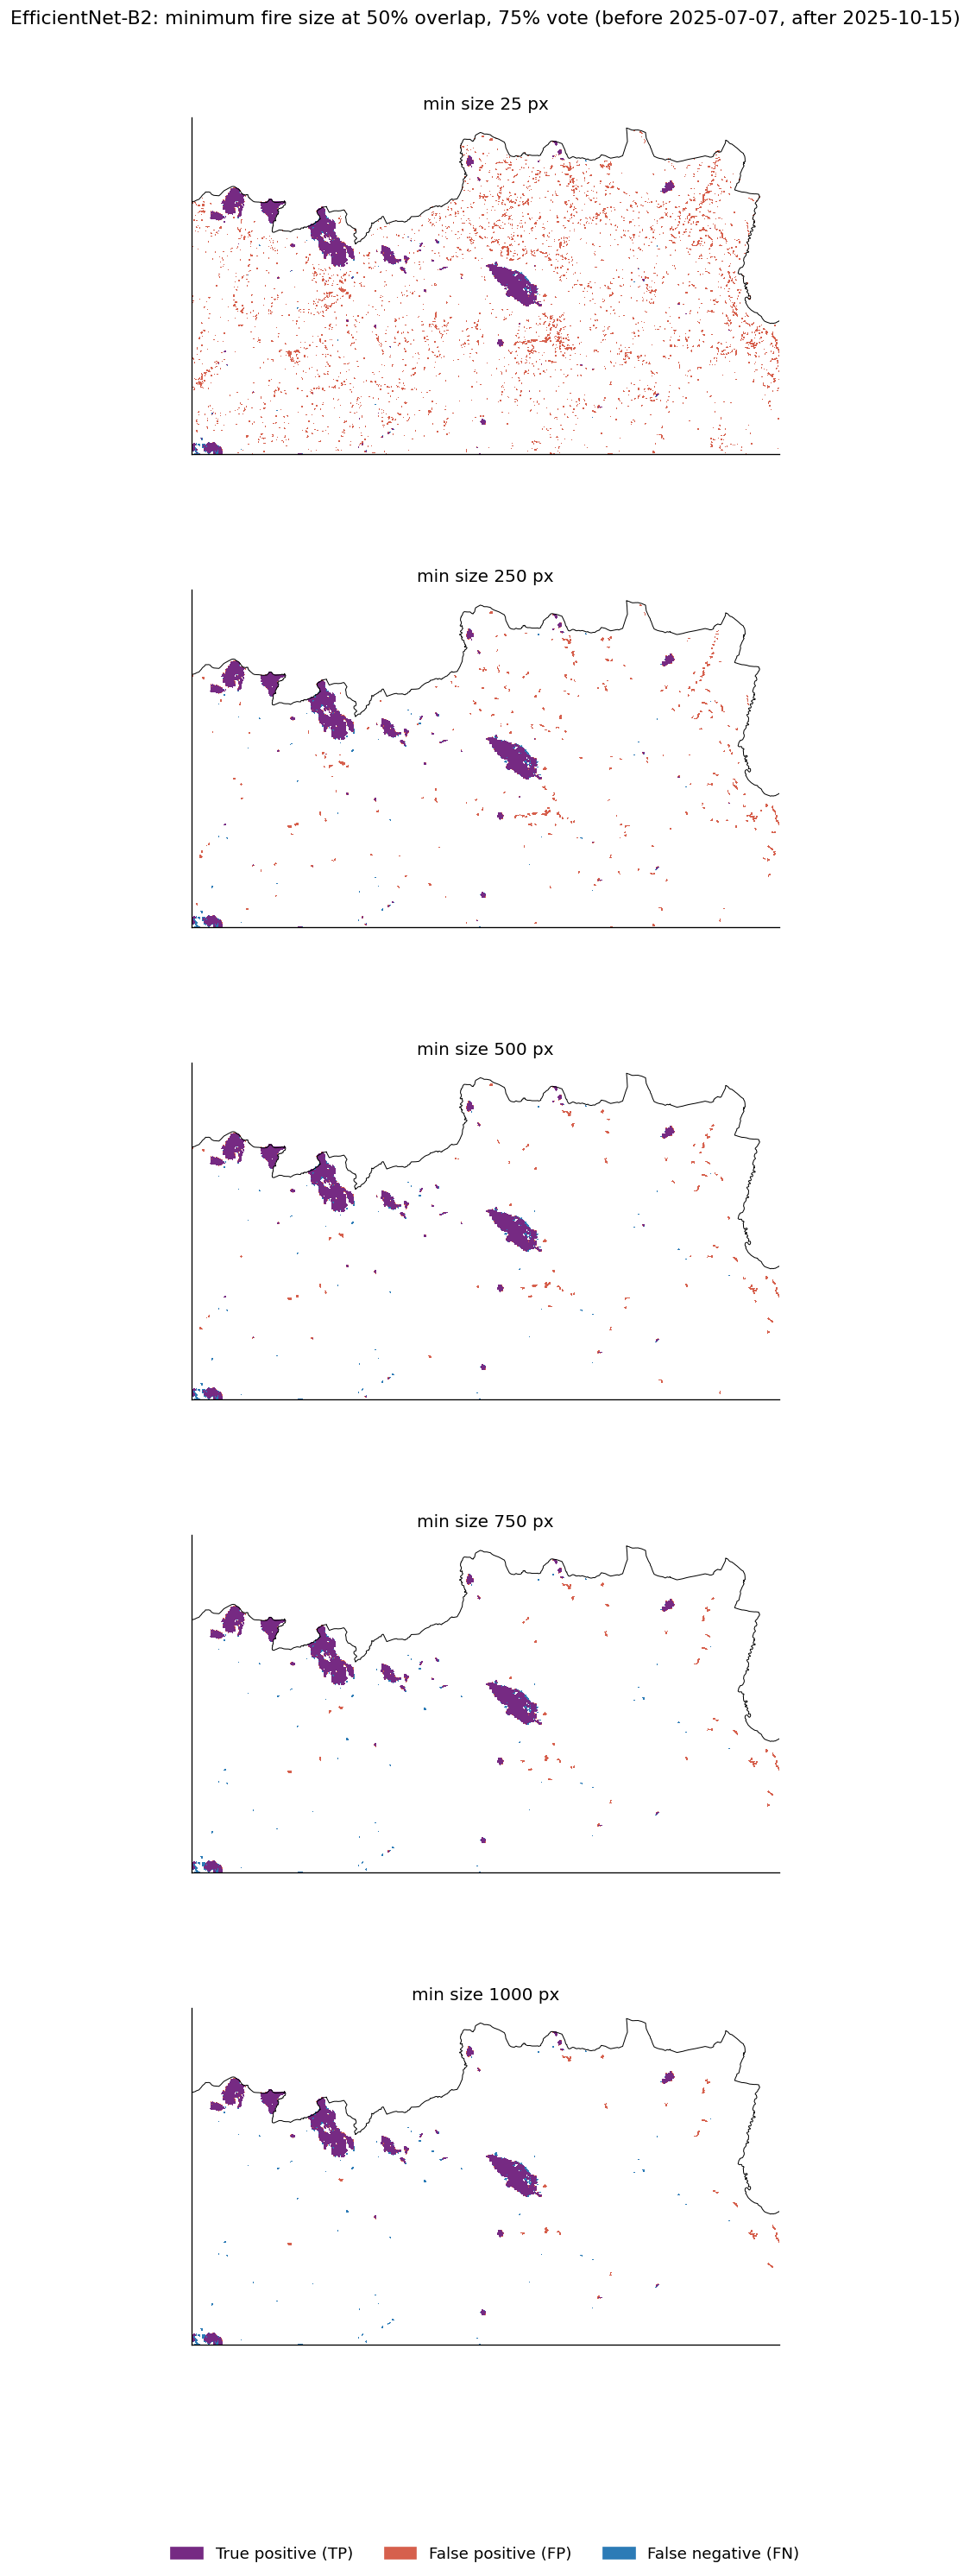

In [56]:
SHOW = [25, 250, 500, 750, 1000]; MAP_VOTE = 75
fig, axes = plt.subplots(len(SHOW), 1, figsize=(6, 5*len(SHOW)))
for ax, ms in zip(np.atleast_1d(axes), SHOW):
    ax.imshow(confusion_rgb(size_filtered(MAP_VOTE, ms)), extent=EXTENT,
              origin="upper", interpolation="nearest")
    PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"min size {ms} px")
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"{MODEL_LABEL}: minimum fire size at 50% overlap, {MAP_VOTE}% vote "
             f"(before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

In [57]:
summary_rows = []
for ms in SHOW:
    pred = size_filtered(MAP_VOTE, ms)
    TP = int((pred & t).sum())
    FP = int((pred & ~t).sum())
    FN = int((~pred & t).sum())
    summary_rows.append({"min_size_px": ms, "TP": TP, "FP": FP, "FN": FN, **scores(pred)})
summary_table = pd.DataFrame(summary_rows).round(
    {"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3}
)
summary_table

,min_size_px,TP,FP,FN,burned_ha,precision,recall,F1,MCC
0,25,969438,518870,94189,14883.0,0.651,0.911,0.760,0.765
1,250,964390,230268,99237,11947.0,0.807,0.907,0.854,0.852
2,500,961499,154605,102128,11161.0,0.861,0.904,0.882,0.880
3,750,956225,131266,107402,10875.0,0.879,0.899,0.889,0.887
4,1000,954869,115198,108758,10701.0,0.892,0.898,0.895,0.893


*Observation.* as minimum pixel size increases, scattered red specks thin out while the compact fires stay

*Interpretation.* Minimum pixel size makes a clear improvement to FP rate reduction, creating a much cleaner result without generating mroe false negatives and therefore missing fires. The graph of min fire size vs evaluation score decelerates towards 500 pixels but the plataue may be higher, could run again with higher minimum pixel counts to see where it levels off and begins to produce false negatives. The success rate is influenced by the vote percentage, with a bigger effect seen with 75% voting strictness.

#### 4.1.3 How does increasing the pixel threshold impact on accuracy of burned area vs fire number detection?

*Objective* Investigate the implications of changing the minimum pixel threshole on the model's ability to detect numbers of fires and burned area accurately. 

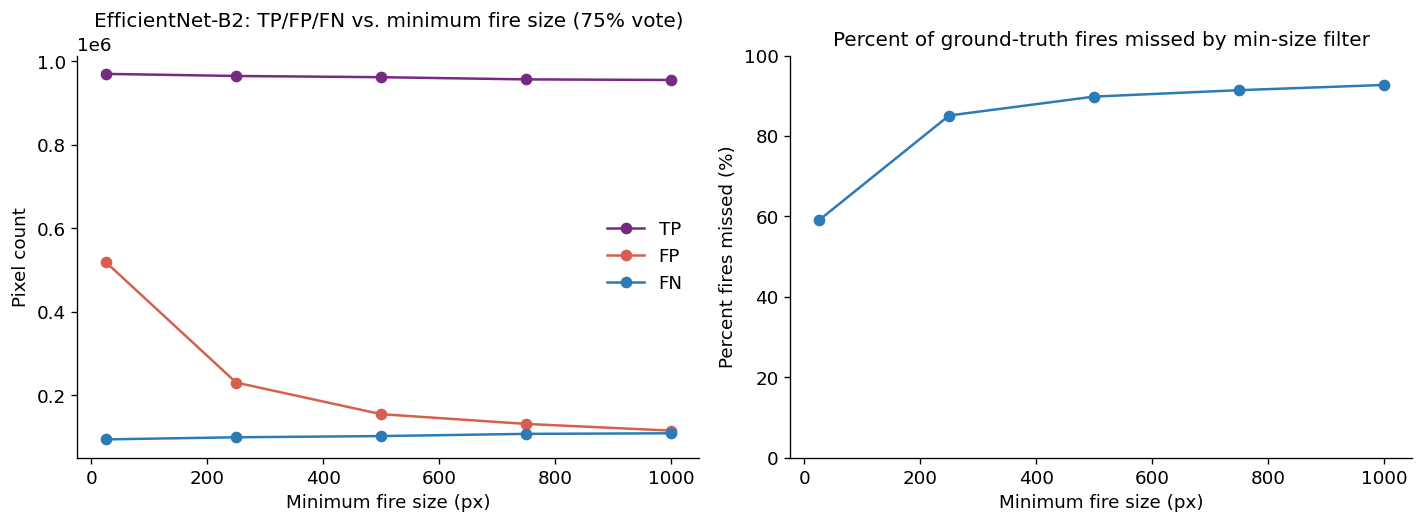

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: TP / FP / FN (same as previous)
ax = axes[0]
ax.plot(summary_table["min_size_px"], summary_table["TP"], marker="o", color=C_AGREE, label="TP")
ax.plot(summary_table["min_size_px"], summary_table["FP"], marker="o", color=C_FALSE, label="FP")
ax.plot(summary_table["min_size_px"], summary_table["FN"], marker="o", color=C_MISS,  label="FN")
ax.set_xlabel("Minimum fire size (px)")
ax.set_ylabel("Pixel count")
ax.set_title(f"{MODEL_LABEL}: TP/FP/FN vs. minimum fire size ({MAP_VOTE}% vote)")
ax.legend()

# right: percent of ground-truth fires missed
ax = axes[1]
ax.plot(miss_table["min_size_px"], miss_table["pct_fires_missed"], marker="o", color=C_MISS)
ax.set_xlabel("Minimum fire size (px)")
ax.set_ylabel("Percent fires missed (%)")
ax.set_ylim(0, 100)
ax.set_title("Percent of ground-truth fires missed by min-size filter")

plt.tight_layout()
plt.show()

In [59]:
total_area = gt_sizes.sum()

rows = []
for ms in SHOW:
    pred = size_filtered(MAP_VOTE, ms)
    TP = int((pred & t).sum())
    FP = int((pred & ~t).sum())
    FN = int((~pred & t).sum())

    n_missed = int((gt_sizes < ms).sum())
    area_missed = int(gt_sizes[gt_sizes < ms].sum())

    rows.append({
        "min_size_px": ms,
        "TP": TP, "FP": FP, "FN": FN,
        "n_fires_missed": n_missed, "n_fires_total": len(gt_sizes),
        "pct_fires_missed": n_missed / len(gt_sizes) * 100,
        "ha_missed": area_missed * PIX_HA,
        "pct_area_missed": area_missed / total_area * 100,
    })

comparison_table = pd.DataFrame(rows).round(
    {"pct_fires_missed": 1, "ha_missed": 1, "pct_area_missed": 2}
)
comparison_table

,min_size_px,TP,FP,FN,n_fires_missed,n_fires_total,pct_fires_missed,ha_missed,pct_area_missed
0,25,969438,518870,94189,226,383,59.0,9.3,0.09
1,250,964390,230268,99237,326,383,85.1,105.2,0.99
2,500,961499,154605,102128,344,383,89.8,169.4,1.59
3,750,956225,131266,107402,350,383,91.4,205.9,1.94
4,1000,954869,115198,108758,355,383,92.7,248.8,2.34


Increasing the pixel results in higher rates of missed instances of fire (up to 92.7%), but overal percentage of burned area missed stayes low (below 3%).

In [60]:
#checking pixel size distribution of ground-truth fires

from scipy.ndimage import label as ndlabel

gt_lab, n_gt = ndlabel(t)
gt_sizes = np.bincount(gt_lab.ravel())[1:]   # drop background label 0

print(f"distinct ground-truth fire patches in window: {n_gt}")
print(f"minimum true-fire size: {gt_sizes.min()} px  ({gt_sizes.min()*PIX_HA:.3f} ha)")
print(f"median: {np.median(gt_sizes):.0f} px, max: {gt_sizes.max()} px")

pd.Series(gt_sizes).sort_values().reset_index(drop=True)

distinct ground-truth fire patches in window: 383
minimum true-fire size: 1 px  (0.010 ha)
median: 9 px, max: 319798 px


0           1
1           1
2           1
3           1
4           1
        ...  
378     45747
379     79457
380    105506
381    296112
382    319798
Length: 383, dtype: int64

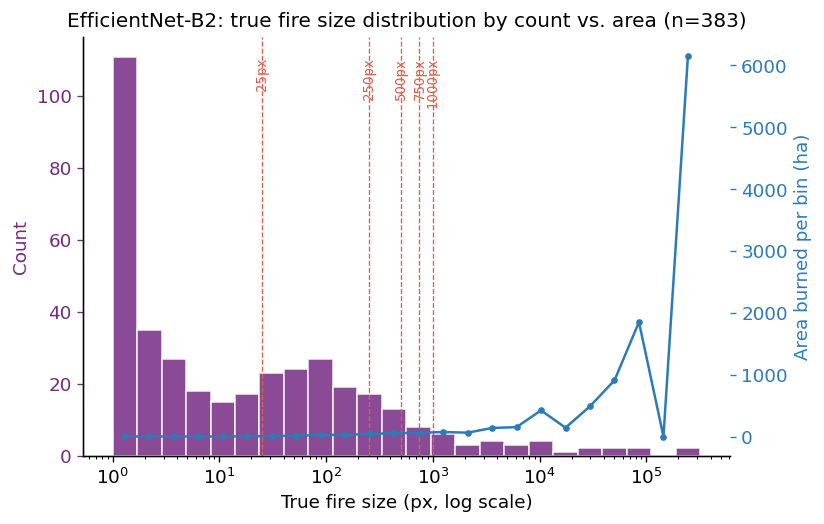

In [61]:
#reviewing the distribution of true fire sizes, both by count and by area burned

fig, ax1 = plt.subplots(figsize=(7, 4.5))
bins = np.logspace(np.log10(gt_sizes.min()), np.log10(gt_sizes.max()), 25)

ax1.hist(gt_sizes, bins=bins, color=C_AGREE, edgecolor="white", alpha=0.85)
ax1.set_xscale("log")
ax1.set_xlabel("True fire size (px, log scale)")
ax1.set_ylabel("Count", color=C_AGREE)
ax1.tick_params(axis="y", colors=C_AGREE)
ax1.set_title(f"{MODEL_LABEL}: true fire size distribution by count vs. area (n={len(gt_sizes)})")

for ms in SHOW:
    ax1.axvline(ms, color=C_FALSE, linestyle="--", linewidth=0.8)
    ax1.text(ms, ax1.get_ylim()[1]*0.95, f"{ms}px", color=C_FALSE, ha="center",
              fontsize=8, rotation=90, va="top")

# Area burned per bin: weight each fire by its own size (px) so the histogram
# sums to total hectares rather than fire count.
bin_centers = np.sqrt(bins[:-1] * bins[1:])   # geometric mean — correct centre for log bins
area_ha, _ = np.histogram(gt_sizes, bins=bins, weights=gt_sizes * PIX_HA)

ax2 = ax1.twinx()
ax2.plot(bin_centers, area_ha, color=C_MISS, marker="o", markersize=3, linewidth=1.5)
ax2.set_ylabel("Area burned per bin (ha)", color=C_MISS)
ax2.tick_params(axis="y", colors=C_MISS)

plt.tight_layout(); plt.show()

*Observation*: Increasing the minimum pixel size threshold cuts off a large proportion of total number of fires because distribution is heavily right skewed with few fires accounting for the highest area burned. 

#### 4.1.4 Determining Optimal threshold for minimum pixel size

*Objective* Taking into account the impact of minimum pixel size on the model's accuracy, how can we reduce false positives without increasing false negatives in relation to smaller fires?

In [63]:
edges = [0, 1, 10, 20, 50, 100, 500, 1000, np.inf]
labs = ["]0-1[", "[1-10[", "[10-20[", "[20-50[", "[50-100[", "[100-500[", "[500-1000[", "[1000+["]

# Swap this for whichever array `best` actually refers to. If best['setting'] names
# a min-size config, use size_filtered(vote_pct, min_size_px) with its real values;
# if it's a plain overlap/vote setting with no size filter, load the matching
# burned_path()/votes_path() raster instead.
pred = size_filtered(75, 500)   # <- replace 75, 500 with best's actual vote_pct / min_size_px

def per_fire_recall(geom, erode_m=10):
    eroded = geom.buffer(-erode_m)
    if eroded.is_empty:
        return np.nan, 0
    fire_mask = rasterize([(eroded, 1)], out_shape=GRID_SHAPE, transform=GRID_T,
                          fill=0, dtype="uint8").astype(bool) & comp
    n = int(fire_mask.sum())
    if n == 0:
        return np.nan, 0
    return int(pred[fire_mask].sum()) / n, n

rows = []
for _, fire in sel.iterrows():
    recall, n_px = per_fire_recall(fire.geometry)
    rows.append({"fire_id": fire["Cod_SGIF"], "area_ha": fire["AreaHaSIG"],
                 "recall": recall, "n_evaluated_px": n_px})
fire_results = pd.DataFrame(rows)
fire_results["size_class"] = pd.cut(fire_results["area_ha"], bins=edges, labels=labs, right=False)

cls = fire_results.groupby("size_class", observed=True).agg(
    fires=("area_ha", "size"), ha=("area_ha", "sum"), recall=("recall", "mean"))
cls["fires_%"] = 100*cls["fires"]/cls["fires"].sum()
cls["ha_%"] = 100*cls["ha"]/cls["ha"].sum()
cls.round({"ha": 1, "fires_%": 1, "ha_%": 1, "recall": 3})

,fires,ha,recall,fires_%,ha_%
size_class,,,,,
]0-1[,31,19.0,0.148,24.6,0.2
[1-10[,70,217.0,0.341,55.6,1.8
[10-20[,8,113.9,0.700,6.3,0.9
[20-50[,3,88.4,0.992,2.4,0.7
[50-100[,3,207.9,0.976,2.4,1.7
[100-500[,6,1515.1,0.940,4.8,12.5
[500-1000[,2,1499.7,0.673,1.6,12.4
[1000+[,3,8458.3,0.933,2.4,69.8


In [67]:
def per_fire_recall_with(geom, pred, erode_m=10):
    eroded = geom.buffer(-erode_m)
    if eroded.is_empty:
        return np.nan, 0
    fire_mask = rasterize([(eroded, 1)], out_shape=GRID_SHAPE, transform=GRID_T,
                          fill=0, dtype="uint8").astype(bool) & comp
    n = int(fire_mask.sum())
    if n == 0:
        return np.nan, 0
    return int(pred[fire_mask].sum()) / n, n

v = read(votes_path(50))                      # adjust overlap to whatever MAP_VOTE used
raw_pred = (v != 255) & (v >= 75) & comp       # vote >= 75%, no min-size filter

rows = []
for _, fire in sel.iterrows():
    recall, n_px = per_fire_recall_with(fire.geometry, raw_pred)  # same fn, swap pred in
    rows.append({"fire_id": fire["Cod_SGIF"], "area_ha": fire["AreaHaSIG"], "recall": recall})
raw_results = pd.DataFrame(rows)
raw_results["size_class"] = pd.cut(raw_results["area_ha"], bins=edges, labels=labs, right=False)
raw_results.groupby("size_class", observed=True)["recall"].mean().round(3)

size_class
]0-1[         0.385
[1-10[        0.796
[10-20[       0.912
[20-50[       0.992
[50-100[      0.977
[100-500[     0.940
[500-1000[    0.694
[1000+[       0.935
Name: recall, dtype: float64

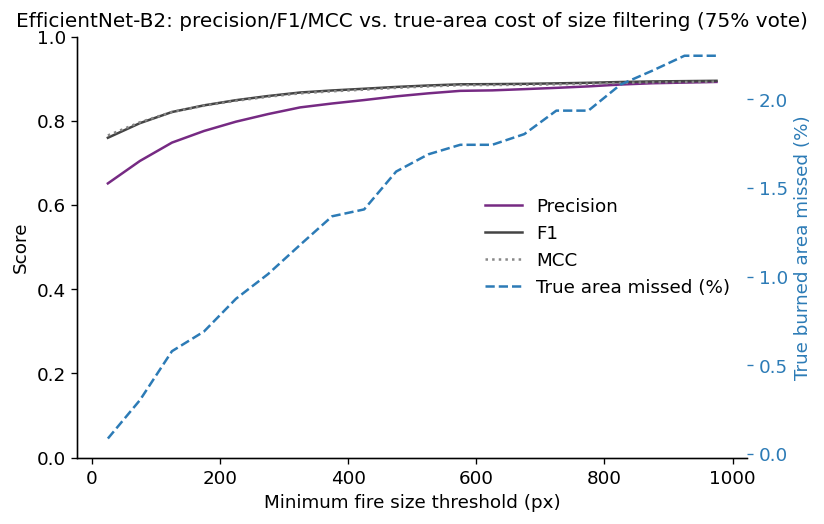

In [ ]:
total_area = gt_sizes.sum()  

area_curve = pd.Series(
    {ms: gt_sizes[gt_sizes < ms].sum() / total_area * 100 for ms in THRESHOLDS},
    name="pct_area_missed"
)
stats75 = size_stats[size_stats["vote_pct"] == MAP_VOTE].set_index("min_size_px")

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(stats75.index, stats75["precision"], color=C_AGREE, label="Precision")
ax1.plot(stats75.index, stats75["F1"], color="#444444", label="F1")
ax1.plot(stats75.index, stats75["MCC"], color="#888888", linestyle=":", label="MCC")
ax1.set_xlabel("Minimum fire size threshold (px)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(area_curve.index, area_curve.values, color=C_MISS, linestyle="--", label="True area missed (%)")
ax2.set_ylabel("True burned area missed (%)", color=C_MISS)
ax2.tick_params(axis="y", colors=C_MISS)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.set_title(f"{MODEL_LABEL}: precision/F1/MCC vs. true-area cost of size filtering ({MAP_VOTE}% vote)")
plt.tight_layout(); plt.show()

In [ ]:
combined["d_precision"] = combined["precision"].diff()
combined["d_area_missed"] = combined["pct_area_missed"].diff()
combined["gain_per_cost"] = combined["d_precision"] / combined["d_area_missed"]
combined

,precision,F1,MCC,pct_area_missed,d_precision,d_area_missed,gain_per_cost
min_size_px,,,,,,,
25,0.651369,0.759767,0.765284,0.087625,NaN,NaN,NaN
75,0.704679,0.794480,0.796593,0.304148,0.053310,0.216523,0.246210
125,0.748225,0.820882,0.820967,0.579903,0.043546,0.275755,0.157915
175,0.775844,0.836702,0.835835,0.690938,0.027619,0.111035,0.248738
225,0.798006,0.849006,0.847572,0.875683,0.022162,0.184745,0.119960
275,0.816001,0.858863,0.857100,1.014641,0.017995,0.138958,0.129500
325,0.831849,0.867210,0.865233,1.179173,0.015848,0.164531,0.096324
375,0.841149,0.872096,0.870035,1.340414,0.009299,0.161241,0.057674
425,0.849307,0.876152,0.874030,1.379149,0.008158,0.038735,0.210621


*observation:* efficiency is highest in roughly the 75–300px range and tails off sharply past ~600px. 

In [ ]:
v50 = read(votes_path(MAP_VOTE))                  # raw vote raster, no size filter applied
raw_pred = (v50 != 255) & (v50 >= MAP_VOTE) & comp

detected = np.array([(raw_pred[gt_lab == i]).any() for i in range(1, n_gt + 1)])
print(f"fires with ≥1 true-positive pixel pre-filter: {detected.sum()}/{n_gt} ({detected.mean()*100:.1f}%)")

fires with ≥1 true-positive pixel pre-filter: 204/383 (53.3%)


In [68]:
#checking how many fires are detected at different minimum fire-size thresholds
for ms in [50, 100, 150, 200, 300, 400, 500]:
    pred_ms = size_filtered(75, ms)
    rows = [{"area_ha": f["AreaHaSIG"],
             "recall": per_fire_recall_with(f.geometry, pred_ms)[0]} for _, f in sel.iterrows()]
    r = pd.DataFrame(rows)
    r["size_class"] = pd.cut(r["area_ha"], bins=edges, labels=labs, right=False)
    print(f"min_size={ms}px:")
    print(r.groupby("size_class", observed=True)["recall"].mean().round(3), "\n")

min_size=50px:
size_class
]0-1[         0.336
[1-10[        0.783
[10-20[       0.912
[20-50[       0.992
[50-100[      0.977
[100-500[     0.940
[500-1000[    0.693
[1000+[       0.935
Name: recall, dtype: float64 

min_size=100px:
size_class
]0-1[         0.281
[1-10[        0.732
[10-20[       0.882
[20-50[       0.992
[50-100[      0.976
[100-500[     0.940
[500-1000[    0.690
[1000+[       0.935
Name: recall, dtype: float64 

min_size=150px:
size_class
]0-1[         0.247
[1-10[        0.681
[10-20[       0.882
[20-50[       0.992
[50-100[      0.976
[100-500[     0.940
[500-1000[    0.681
[1000+[       0.934
Name: recall, dtype: float64 

min_size=200px:
size_class
]0-1[         0.215
[1-10[        0.591
[10-20[       0.792
[20-50[       0.992
[50-100[      0.976
[100-500[     0.940
[500-1000[    0.675
[1000+[       0.934
Name: recall, dtype: float64 

min_size=300px:
size_class
]0-1[         0.181
[1-10[        0.424
[10-20[       0.792
[20-50[       0.992
[50-100[      0.976
[1

**Observation.** Per-fire recall declined monotonically with increasing min_size_px for fires below 20 ha, most sharply in the [1–10[ ha class (0.796 raw → 0.341 at 500 px) and [10–20[ ha class (0.912 → 0.700), with the rate of loss accelerating beyond ~150–200 px. Recall for fires ≥20 ha was invariant across the entire 0–500 px range, while the ]0–1[ ha class showed comparatively low recall even without filtering (0.385).

**Interpretation.** The size filter suppresses true detections in the 1–20 ha range rather than false positives, and this loss is masked in area-weighted aggregate metrics because that stratum contributes negligible total burned area. A threshold of 100 px (1 ha) is the better-justified setting: it aligns with ICNF's own ]0–1[/[1–10[ class boundary, preserves most of the genuine signal in the 1–20 ha classes (within ~3–6pp of raw recall), and confines its cost mainly to the ]0–1[ class, which is already near the model's detection limit regardless of filtering.

**Conclusion:** min_size_px ≈ 100 (1 ha)

## 5. Threshold curves

Using the vote fraction as a soft score, we draw the ROC and precision-recall
curves. Given the strong class imbalance, precision-recall is the honest summary
and ROC is reported but optimistic.

### 5.1 ROC and precision-recall

#### 5.1.1 Curves from the vote fraction

**Objective.** Build ROC and precision-recall curves for the 50 and 75 percent
overlap vote fractions. **Assumption.** Score is the percent of windows voting
burned.

In [ ]:
def curve_counts(votes):
    m = (votes != 255) & scored; s = votes[m]; y = truth[m]
    P = int(y.sum()); N = int((~y).sum())
    hp = np.bincount(s[y], minlength=101).astype(float)
    hn = np.bincount(s[~y], minlength=101).astype(float)
    tp = np.cumsum(hp[::-1])[::-1]; fp = np.cumsum(hn[::-1])[::-1]
    return tp, fp, P, N

roc, pr = {}, {}
for ov in VOTE_OVERLAPS:
    tp, fp, P, N = curve_counts(read(votes_path(ov)))
    tpr = np.concatenate([[0.0], tp/P]); fpr = np.concatenate([[0.0], fp/N])
    o = np.argsort(fpr); roc[ov] = (fpr[o], tpr[o], float(np.trapezoid(tpr[o], fpr[o])))
    recall = tp/P; precision = np.where(tp+fp > 0, tp/np.maximum(tp+fp, 1), 1.0)
    oo = np.argsort(recall)
    rs = np.concatenate([[0.0], recall[oo]]); ps = np.concatenate([[precision[oo][0]], precision[oo]])
    pr[ov] = (rs, ps, float(np.sum(np.diff(rs)*ps[1:])))
pd.DataFrame([{"overlap": ov, "ROC_AUC": round(roc[ov][2], 3), "PR_AP": round(pr[ov][2], 3)}
              for ov in VOTE_OVERLAPS])

AttributeError: module 'numpy' has no attribute 'trapezoid'

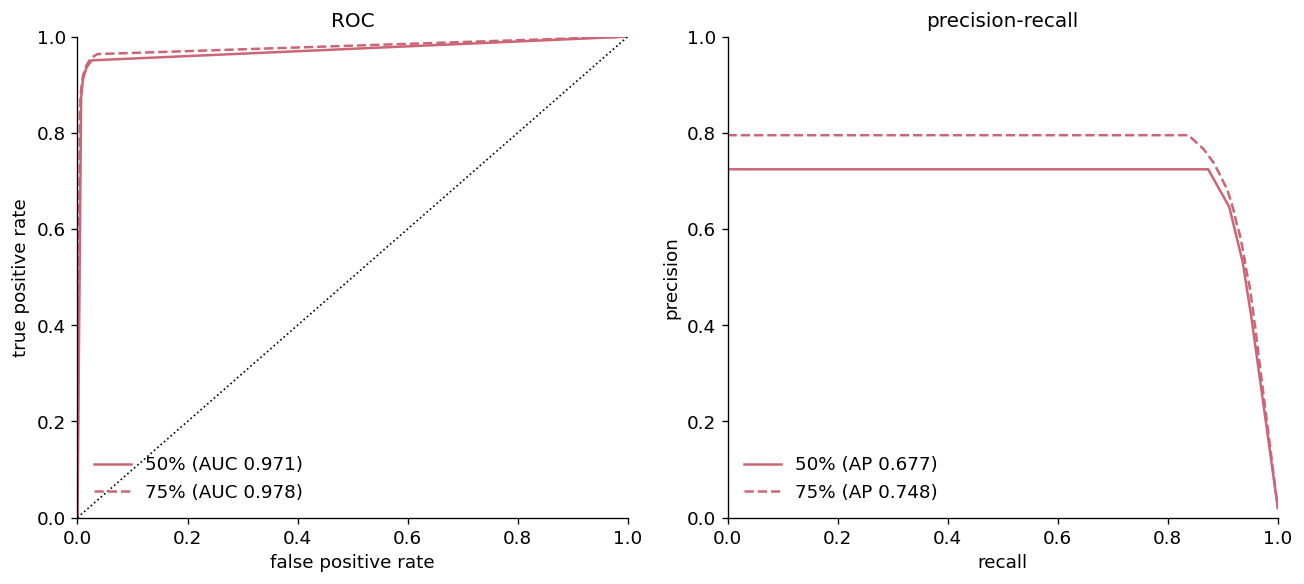

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ov in VOTE_OVERLAPS:
    ls = "-" if ov == 50 else "--"
    fpr, tpr, auc = roc[ov]; axes[0].plot(fpr, tpr, ls, color=MCOLOR, label=f"{ov}% (AUC {auc:.3f})")
    rs, ps, ap = pr[ov]; axes[1].plot(rs, ps, ls, color=MCOLOR, label=f"{ov}% (AP {ap:.3f})")
axes[0].plot([0, 1], [0, 1], "k:", lw=1); axes[0].set_title("ROC")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[1].set_title("precision-recall"); axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
for ax in axes: ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

*Observation.* The ROC areas look near-perfect, but that is the imbalance
flattering the result; the precision-recall average precision is the trustworthy
number for this rare-event problem, and it improves with overlap.

## 6. Summary

Deployed over the full tile, EfficientNet-B2 produces sensible burned-area maps
that land on the real fires. Three post-processing levers each cut the scattered
seasonal false alarms while keeping the fires: overlapping the windows and voting,
making that vote stricter, and removing small predicted patches. Run time grows
steeply with overlap while memory stays roughly flat. The precision-recall view
(average precision) is the honest accuracy summary, since the ROC is optimistic
under the heavy class imbalance. All numbers rest on the EfficientNet band order,
which should be confirmed with the model author before they are treated as final.

## 7. Optimum setting

Finally, we pool every configuration tested in this notebook (overlap with the
majority vote, the voting-strictness thresholds, and the minimum fire-size sweep)
and pick the best operating point. We rank by MCC, the single-number summary for an
imbalanced binary problem, and report the top settings. The winning row is the
recommended EfficientNet deployment setting for this tile and scene pair.

In [ ]:
# pool all tested configurations and rank by MCC
_cols = ("burned_ha", "precision", "recall", "F1", "MCC")
configs = []
for _, r in overlap_stats.iterrows():
    configs.append({"setting": f"overlap {int(r.overlap)}%, majority vote",
                    **{k: r[k] for k in _cols}})
for _, r in strict_stats.iterrows():
    configs.append({"setting": f"overlap {int(r.overlap)}%, vote >= {int(r.vote_pct)}%",
                    **{k: r[k] for k in _cols}})
for _, r in size_stats.iterrows():
    configs.append({"setting": f"overlap 50%, vote >= {int(r.vote_pct)}%, "
                               f"min size {int(r.min_size_px)} px",
                    **{k: r[k] for k in _cols}})
ranking = pd.DataFrame(configs).sort_values("MCC", ascending=False).reset_index(drop=True)

best = ranking.iloc[0]
print("OPTIMUM EfficientNet-B2 SETTING (ranked by MCC)")
print(f"  -> {best['setting']}")
print(f"     MCC={best.MCC:.3f}  F1={best.F1:.3f}  precision={best.precision:.3f}  "
      f"recall={best.recall:.3f}")
print(f"     burned {best.burned_ha:,.0f} ha  (actual fire in window {t.sum()*PIX_HA:,.0f} ha)")
print("\nTop 8 configurations:")
ranking.head(8).round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

OPTIMUM EfficientNet-B2 SETTING (ranked by MCC)
  -> overlap 50%, vote >= 75%, min size 500 px
     MCC=0.880  F1=0.882  precision=0.861  recall=0.904
     burned 11,161 ha  (actual fire in window 10,636 ha)

Top 8 configurations:


,setting,burned_ha,precision,recall,F1,MCC
0,"overlap 50%, vote >= 75%, min size 500 px",11161.0,0.861,0.904,0.882,0.880
1,"overlap 50%, vote >= 75%, min size 475 px",11205.0,0.858,0.904,0.880,0.878
2,"overlap 50%, vote >= 75%, min size 450 px",11274.0,0.853,0.904,0.878,0.876
3,"overlap 50%, vote >= 75%, min size 425 px",11331.0,0.849,0.905,0.876,0.874
4,"overlap 50%, vote >= 75%, min size 400 px",11376.0,0.846,0.905,0.875,0.873
5,"overlap 50%, vote >= 75%, min size 375 px",11449.0,0.841,0.905,0.872,0.870
6,"overlap 50%, vote >= 75%, min size 350 px",11521.0,0.836,0.906,0.870,0.868
7,"overlap 50%, vote >= 75%, min size 325 px",11581.0,0.832,0.906,0.867,0.865
